# TITLE and IMPORTS

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.metrics import precision_recall_curve, roc_auc_score, f1_score 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier 
from imblearn.over_sampling import SMOTE 
import shap 

import warnings 
warnings.filterwarnings('ignore')

# LOAD DATASET

In [2]:
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## **BASIC INSPECTION**

In [4]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## **Class Imbalance Check**

Class
0    284315
1       492
Name: count, dtype: int64


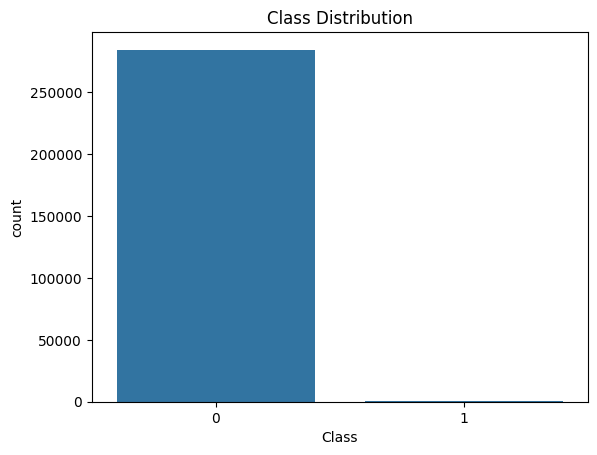

In [5]:
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.savefig("Class_distribution", dpi=300, bbox_inches='tight')
plt.show()


## **Amount Distribution**

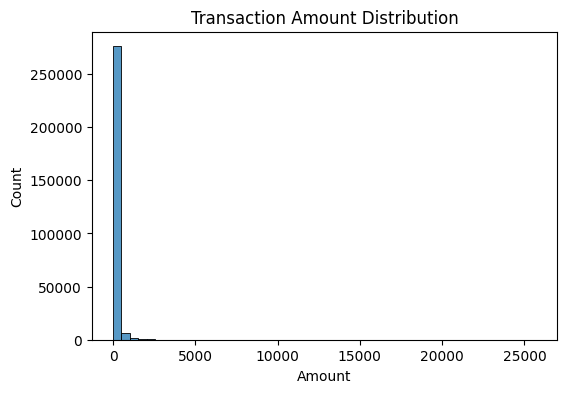

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()


## **Train Test Split (STRATIFIED – very important)**

In [7]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", y_train.value_counts())
print("Test:", y_test.value_counts())


Train: Class
0    227451
1       394
Name: count, dtype: int64
Test: Class
0    56864
1       98
Name: count, dtype: int64


# LOGISTIC RESGRESSION BASELINE (Baseline Model)

In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.91      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



# **Random Forest Classifier**

In [9]:
rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    random_state=42,
    class_weight='balanced'  # handles imbalance
)

# Train model
rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)

# Evaluation
print("Random Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



# YOUR MAIN CONTRIBUTION – THRESHOLD OPTIMIZATION

## **XG-Boost**

In [10]:
xgb = XGBClassifier(
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

# Predictions
xgb_pred = xgb.predict(X_test)

# Classification Report
print("XGBoost Classification Report:\n")
print(classification_report(y_test, xgb_pred))



XGBoost Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



# Calibration Cell

In [11]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report

# -------------------------------
# CALIBRATE XGBOOST
# -------------------------------
calibrated = CalibratedClassifierCV(xgb, method='sigmoid', cv=3)
calibrated.fit(X_train, y_train)

# -------------------------------
# GET PROBABILITIES FROM ALL MODELS
# -------------------------------
prob_lr = lr.predict_proba(X_test)[:,1]
prob_rf = rf.predict_proba(X_test)[:,1]
prob_xgb = calibrated.predict_proba(X_test)[:,1]  # calibrated XGB

# -------------------------------
# ENSEMBLE (AVERAGING)
# -------------------------------
prob = (prob_lr + prob_rf + prob_xgb) / 3

# -------------------------------
# TEMP EVALUATION (threshold = 0.5)
# -------------------------------
cal_pred = (prob > 0.5).astype(int)

print("Ensemble Model (Threshold = 0.5)\n")
print(classification_report(y_test, cal_pred))

Ensemble Model (Threshold = 0.5)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



# **RESULTS**

## **1) PR-AUC Curve**

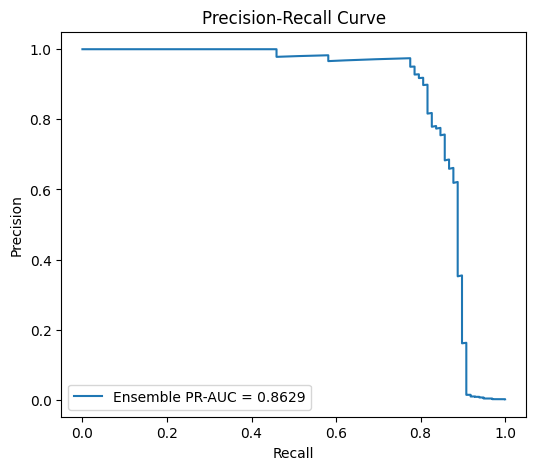

PR-AUC: 0.8628998896229347


<Figure size 640x480 with 0 Axes>

In [14]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, th = precision_recall_curve(y_test, prob)
 
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'Ensemble PR-AUC = {pr_auc:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

plt.savefig("PR-AUC", dpi=300, bbox_inches='tight')
print("PR-AUC:", pr_auc)


## **2) THRESHOLD STUDY TABLE**

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []

for t in np.arange(0.1, 0.9, 0.05):
    p = (prob >= t).astype(int)

    rows.append([
        t,
        precision_score(y_test, p),
        recall_score(y_test, p),
        f1_score(y_test, p)
    ])

table = pd.DataFrame(rows, columns=['Threshold','Precision','Recall','F1'])
table.sort_values(by='F1', ascending=False).head(10)



,Threshold,Precision,Recall,F1
8,0.50,0.974359,0.775510,0.863636
6,0.40,0.917647,0.795918,0.852459
7,0.45,0.927711,0.785714,0.850829
5,0.35,0.860215,0.816327,0.837696
9,0.55,0.972973,0.734694,0.837209
10,0.60,0.972973,0.734694,0.837209
11,0.65,0.972222,0.714286,0.823529
3,0.25,0.810000,0.826531,0.818182
4,0.30,0.816327,0.816327,0.816327
2,0.20,0.780952,0.836735,0.807882


### **3) SELECT BEST THRESHOLD**

In [16]:
best = table.sort_values(by='F1', ascending=False).iloc[0]

best_t = best['Threshold']
print("Best Threshold:", best_t)


Best Threshold: 0.5000000000000001


In [17]:
# Choose threshold where Recall >= 0.75 but highest F1
candidates = table[table['Recall'] >= 0.75]
best = candidates.sort_values(by='F1', ascending=False).iloc[0]

best_t = best['Threshold']
print("Business-aware Threshold:", best_t)

final_pred = (prob >= best_t).astype(int)
print(classification_report(y_test, final_pred))

Business-aware Threshold: 0.5000000000000001
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## **4) FINAL REPORT**

Final Threshold: 0.5000000000000001

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Final Threshold: 0.5000000000000001
ROC-AUC: 0.9557043730547932
PR-AUC: 0.8628998896229347


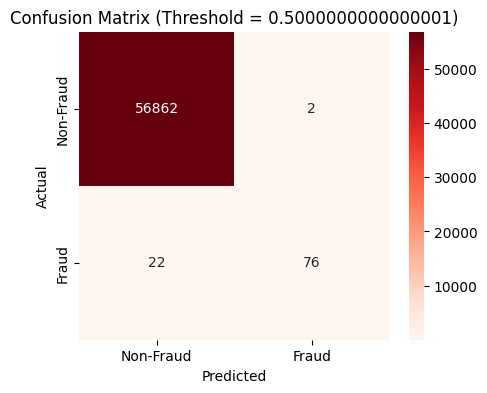

In [21]:
# -------------------------------
# FINAL MODEL EVALUATION
# -------------------------------

final_t = best_t
final_pred = (prob >= final_t).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Final Threshold:", final_t)
print("\nClassification Report:\n")
print(classification_report(y_test, final_pred))

# ROC-AUC
roc = roc_auc_score(y_test, prob)

print("Final Threshold:", final_t)
print("ROC-AUC:", roc)
print("PR-AUC:", pr_auc)

# Confusion Matrix
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title(f"Confusion Matrix (Threshold = {final_t})")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks([0.5, 1.5], ['Non-Fraud', 'Fraud'])
plt.yticks([0.5, 1.5], ['Non-Fraud', 'Fraud'])
plt.savefig("Confusion_matrix", dpi=300, bbox_inches='tight')
plt.show()

## **FINAL SHAP BLOCK (Using CALIBRATED Model)**

PermutationExplainer explainer: 1001it [10:04,  1.64it/s]                          


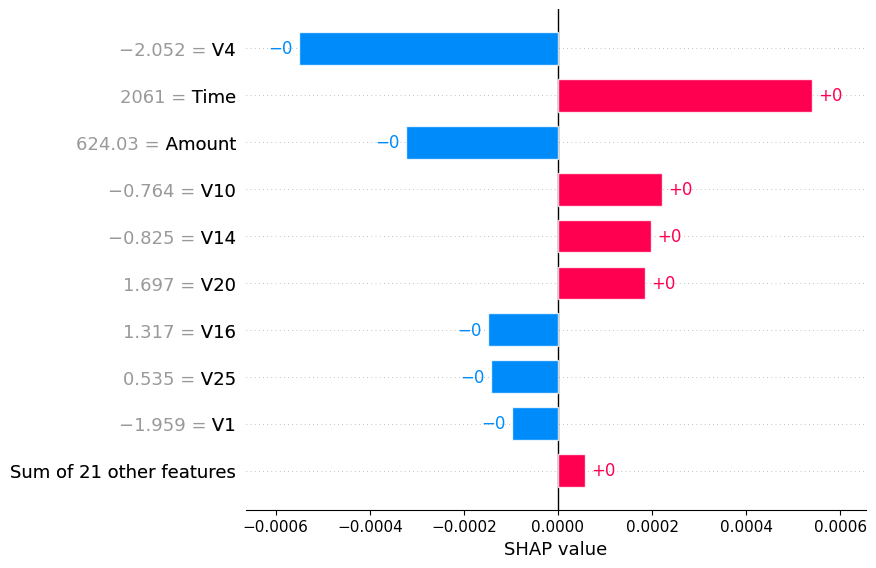

In [20]:
# -------------------------------
# FINAL SHAP EXPLAINABILITY (ENSEMBLE)
# -------------------------------

import shap

# Sample smaller set for faster explanation
X_sample = X_test.sample(1000, random_state=42)

# Define ensemble prediction function
def ensemble_predict(data):
    prob_lr = lr.predict_proba(data)[:,1]
    prob_rf = rf.predict_proba(data)[:,1]
    prob_xgb = calibrated.predict_proba(data)[:,1]
    
    return (prob_lr + prob_rf + prob_xgb) / 3

# SHAP explainer
explainer = shap.Explainer(ensemble_predict, X_sample)

shap_values = explainer(X_sample)

# Global feature importance
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig("shap_bar.png", dpi=300, bbox_inches='tight')
plt.close()

# Local explanation for one transaction
shap.plots.bar(shap_values[0])

plt.savefig("shap_local_bar.png", dpi=300, bbox_inches='tight')
plt.close()

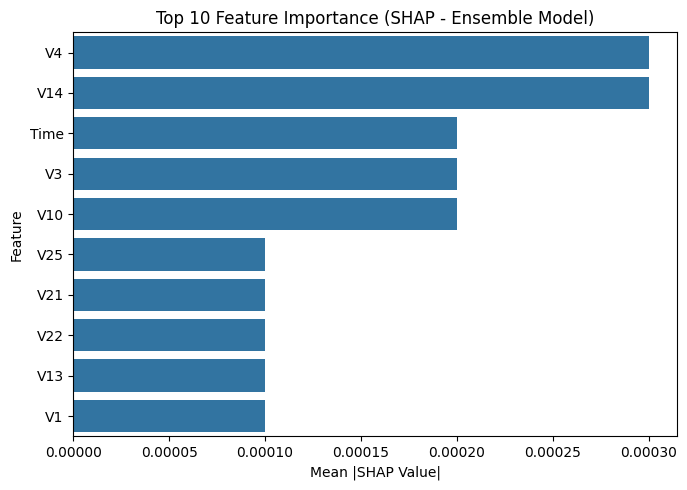

In [22]:
# -------------------------------
# SHAP FEATURE IMPORTANCE (FINAL)
# -------------------------------

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mean absolute SHAP values
shap_importance = np.abs(shap_values.values).mean(axis=0)

# Convert to DataFrame
importance_df = pd.DataFrame({
    'Feature': X_sample.columns,
    'Importance': shap_importance
})

# Sort features
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Take top 10 features
top_features = importance_df.head(10).copy()

# Round values for better display
top_features['Importance'] = top_features['Importance'].round(4)

# -------------------------------
# VISUALIZATION (BAR PLOT - BEST)
# -------------------------------
plt.figure(figsize=(7,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    orient='h'
)

plt.title("Top 10 Feature Importance (SHAP - Ensemble Model)")
plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("shap_topbar.png", dpi=300, bbox_inches='tight')

plt.show()

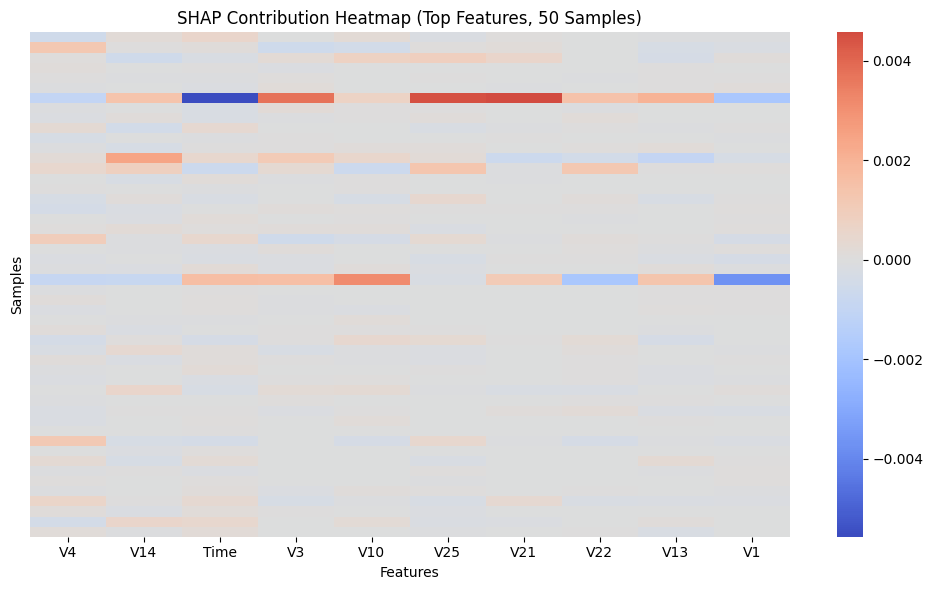

In [23]:
# -------------------------------
# SHAP HEATMAP (IMPROVED)
# -------------------------------

# Take subset for visualization
sample_shap = shap_values.values[:50]

# Convert to DataFrame for better labeling
shap_df = pd.DataFrame(sample_shap, columns=X_sample.columns)

# (Optional) Select top important features only for clarity
top_cols = importance_df['Feature'].head(10).values
shap_df = shap_df[top_cols]

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    shap_df,
    cmap='coolwarm',
    center=0,          # very important (positive vs negative impact)
    xticklabels=True,
    yticklabels=False  # cleaner look
)

plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')

plt.title("SHAP Contribution Heatmap (Top Features, 50 Samples)")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.savefig("Heatmap.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()